In [1]:
print("Hello, World!")

Hello, World!


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

In [4]:
chat_llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [5]:
chat_llm.invoke("What is the capital of France?").content

'The capital of France is **Paris**.'

In [6]:
from typing_extensions import Annotated, TypedDict
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, AIMessage

In [7]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [8]:
["hi", "how are you?"]

['hi', 'how are you?']

In [9]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])
    return {
        "messages": [response]
    }

In [10]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_message = state["messages"][-1]
    text = last_message.content
    token_number = len(text.split())
    summary = f"The last message has {token_number} tokens."
    return {
        "messages": [AIMessage(content=summary)]
    }

In [11]:
from langgraph.graph import StateGraph

In [12]:
builder = StateGraph(GraphState)

In [13]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [14]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [15]:
app = builder.compile()

In [16]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [17]:
from IPython.display import Image, display

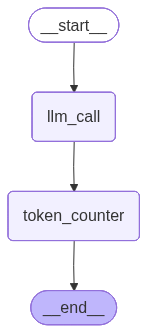

In [18]:
display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
result = app.invoke({
    "messages": [
        SystemMessage(content="You are a helpful assistant."),
        HumanMessage(content="Best way to learn Snowflake?")
    ]
})
result

{'messages': [SystemMessage(content='You are a helpful assistant.', additional_kwargs={}, response_metadata={}),
  HumanMessage(content='Best way to learn Snowflake?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='Learning Snowflake effectively involves a combination of theoretical understanding and hands-on practice. Here\'s a structured approach, from foundational concepts to advanced topics, that many find successful:\n\n## The Best Way to Learn Snowflake: A Step-by-Step Guide\n\n### Phase 1: Prerequisites & Foundation (If you\'re new to data/cloud)\n\n1.  **Strong SQL Skills:** Snowflake is fundamentally a SQL data warehouse. You *must* be proficient in SQL.\n    *   **Focus on:** `SELECT`, `FROM`, `WHERE`, `GROUP BY`, `HAVING`, `ORDER BY`, `JOIN` types, `UNION`, `subqueries`, `CTEs (WITH clause)`, `window functions` (`ROW_NUMBER`, `RANK`, `LEAD`, `LAG`, etc.).\n    *   **Resources:** Mode Analytics SQL Tutorial, LeetCode SQL problems, freeCodeCamp, Khan Academy

In [20]:
for m in result["messages"]:
    print(m.content)

You are a helpful assistant.
Best way to learn Snowflake?
Learning Snowflake effectively involves a combination of theoretical understanding and hands-on practice. Here's a structured approach, from foundational concepts to advanced topics, that many find successful:

## The Best Way to Learn Snowflake: A Step-by-Step Guide

### Phase 1: Prerequisites & Foundation (If you're new to data/cloud)

1.  **Strong SQL Skills:** Snowflake is fundamentally a SQL data warehouse. You *must* be proficient in SQL.
    *   **Focus on:** `SELECT`, `FROM`, `WHERE`, `GROUP BY`, `HAVING`, `ORDER BY`, `JOIN` types, `UNION`, `subqueries`, `CTEs (WITH clause)`, `window functions` (`ROW_NUMBER`, `RANK`, `LEAD`, `LAG`, etc.).
    *   **Resources:** Mode Analytics SQL Tutorial, LeetCode SQL problems, freeCodeCamp, Khan Academy.
2.  **Basic Cloud Concepts (Optional but Recommended):** Snowflake runs on AWS, Azure, or GCP. Understanding basic concepts like object storage (S3, ADLS Gen2, GCS), regions, and avail